# Exercise 1: Familiarize yourself with `pandas`
If you are new to Python, check out the introductory Python courses available through Caltrans's LinkedIn Learning Library:
* https://www.linkedin.com/learning/search?keywords=python&u=36029164

Skills: 
* `pandas` is one of the base Python packages for working with tabular data.
* Do some grouping and aggregation. Many ways to do this!
* Export to Google Cloud Storage
* Practice committing on GitHub

References: 
* https://docs.calitp.org/data-infra/analytics_new_analysts/01-data-analysis-intro.html
* https://docs.calitp.org/data-infra/analytics_tools/saving_code.html

In [1]:
import pandas as pd
from siuba import *
from siuba.data import mtcars

## Groupby / Aggregation

* By cylinder categories, calculate the average mpg and find difference between max and min weight.
* Hint: for `pandas`: `groupby / agg`, `pivot_table`, `groupby / transform`
* Hint: for `siuba`: `groupby`, `summarize`

In [2]:
# what is in `mtcars`?
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
#function that creates pivot tables, based on df, value to aggregate, and aggregate function
def work(df,val,agg):
    new_df = df.pivot_table(
        values=val,
        index='cyl',
        aggfunc=agg
    ).reset_index()
    return new_df

In [4]:
#created new df from the function
mpg_mean= work(mtcars, 'mpg', 'mean')
wt_max= work(mtcars, 'wt', 'max')
wt_min= work(mtcars, 'wt', 'min')

In [5]:
#checking to make sure df display as intended
display(mpg_mean)
display(wt_max)
display(wt_min)

,cyl,mpg
0,4,26.663636
1,6,19.742857
2,8,15.100000


,cyl,wt
0,4,3.190
1,6,3.460
2,8,5.424


,cyl,wt
0,4,1.513
1,6,2.620
2,8,3.170


In [6]:
#mergeing mpg table with max wt table
merge = mpg_mean.merge(wt_max, on='cyl').rename(columns={'wt':'wt_max'})
merge

,cyl,mpg,wt_max
0,4,26.663636,3.190
1,6,19.742857,3.460
2,8,15.100000,5.424


In [7]:
#Taking previous merge, merging with min wt table
merge2 = merge.merge(wt_min, on='cyl').rename(columns={'wt':'wt_min'})
merge2

,cyl,mpg,wt_max,wt_min
0,4,26.663636,3.190,1.513
1,6,19.742857,3.460,2.620
2,8,15.100000,5.424,3.170


In [8]:
#adding final column, wt difference from max and min
mpg_wt = merge2.assign(wt_diff=(merge2.wt_max)-(merge2.wt_min))
mpg_wt

,cyl,mpg,wt_max,wt_min,wt_diff
0,4,26.663636,3.190,1.513,1.677
1,6,19.742857,3.460,2.620,0.840
2,8,15.100000,5.424,3.170,2.254


## Functions

* Create a new column using a lambda function and tag 6 cylinder values with "six", and all other values as "other"
* Write a function that tags each cylinder value with the word (ex: 6 as "six", 8 as "eight")

In [9]:
#dictionary to use
cyl_name = {
    4:'four',
    6:'six',
    8:'eight'}
print(cyl_name)

{4: 'four', 6: 'six', 8: 'eight'}


In [10]:
#using lambda function (only exist in this cell, cant use again in other cells)
mpg_wt['cyl_name'] = mtcars.apply(lambda x: 'six' if x.cyl == 6
                                  else 'other', axis=1)

mpg_wt


,cyl,mpg,wt_max,wt_min,wt_diff,cyl_name
0,4,26.663636,3.190,1.513,1.677,six
1,6,19.742857,3.460,2.620,0.840,six
2,8,15.100000,5.424,3.170,2.254,other


In [11]:
#using function
def cylname(x):
    if x.cyl ==4:
        return 'four'
    elif x.cyl == 6:
        return 'six'
    elif x.cyl ==8:
        return 'eight'

In [12]:
#apply() method is to apply function along an axis (0= applies to rows, 1= apply to column)
mtcars['cyl_name2'] = mtcars.apply(cylname, axis=1)
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cyl_name2
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,six
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,six
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,four
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,six
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,eight


## Export to Google Cloud Storage (GCS)

* Make sure credential works
* Use this path: "gs://calitp-analytics-data/data-analyses/FILENAME"
* Export using `df.to_parquet()` and `df.to_csv()`

## Make a chart

* Read in the parquet file from GCS.
* Make a visualization using one of the charting packages.
* Name this notebook `YOURNAME_exercise1.ipynb`
    * If you need to rename because you already named it, do it within the terminal.
    * `git mv OLDNAME.ipynb NEWNAME.ipynb`. 
    * The `mv` stands for move, and renaming a file is basically "moving" its path. Doing it this way retains the git history associated with the notebook. If you rename directly with right click, rename, you destroy the git history.
* Use a descriptive commit message (ex: adding chart, etc). GitHub already tracks who makes the commit, the date, the timestamp of it, the files being affected, so your commit message should be more descriptive than the metadata already stored.

In [13]:
df = pd.read_parquet('gs://calitp-analytics-data/data-analyses/csuyat_folder/exercise1_v2.parquet')
df

/opt/conda/lib/python3.9/site-packages/google/auth/_default.py:78: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cyl_cat
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,six
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,six
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,four
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,six
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,eight
5,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1,six
6,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4,eight
7,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2,four
8,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2,four
9,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4,six


<AxesSubplot:xlabel='cyl'>

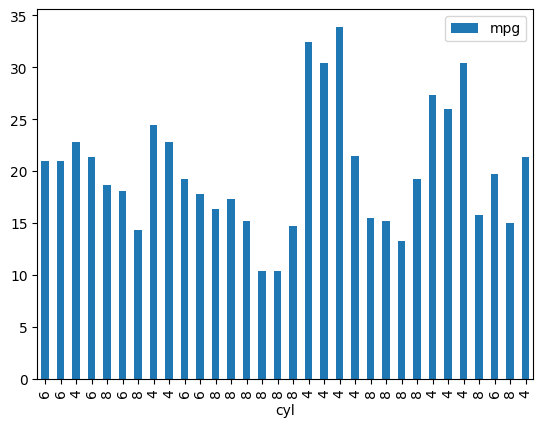

In [14]:
df.plot.bar(x='cyl', y='mpg')

<AxesSubplot:xlabel='cyl'>

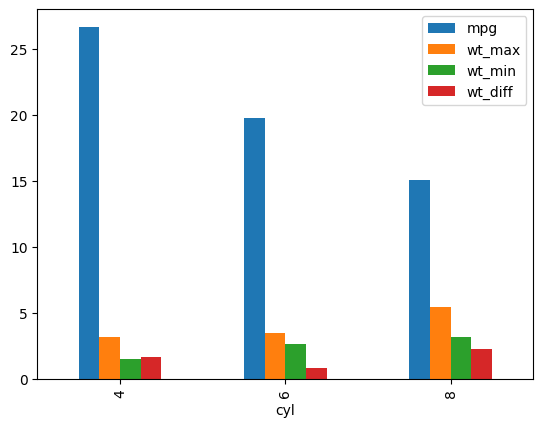

In [15]:
mpg_wt.plot.bar(x='cyl')